# Kiểm tra pipeline phân loại đa nhãn (theo góp ý của giáo sư hướng dẫn)

Giáo sư đề nghị kiểm tra lại pipeline theo 2 hướng trước khi kết luận vì sao mAP/F1 thấp:

1. **Kiểm tra tokenize**: xem bước tokenize (title -> input_ids) có bị lỗi (truncate, UNK, lệch hàng title/nhãn) hay không.
2. **Thử nghiệm kiểm soát 10 lớp x 100 mẫu**: thu nhỏ bài toán về 10 lớp, mỗi lớp 100 mẫu, chạy đúng pipeline hiện tại.
   - Nếu thí nghiệm nhỏ **vẫn cho kết quả kém** -> nghi ngờ lỗi pipeline (tokenize/label alignment/loss).
   - Nếu thí nghiệm nhỏ **cho kết quả tốt** nhưng dataset đầy đủ (99 lớp) vẫn kém -> nghi ngờ **ít ví dụ/long-tail** hoặc **các lớp giao nhau về ngữ nghĩa** khi mở rộng quy mô.

Notebook này chạy tuần tự các bước kiểm tra, in ra bảng số liệu / vẽ biểu đồ để bạn log lại kết quả phục vụ báo cáo.

> Lưu ý: chạy notebook này bằng Python environment đã có `torch`, `transformers`, `pandas`, `scikit-learn` (ví dụ conda env `base` ở `~/miniforge3`), không phải Python hệ thống mặc định.

In [1]:
import os
import random
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from transformers import AutoTokenizer, get_linear_schedule_with_warmup

from dataset import (
    LABEL_COLUMNS,
    PapersDataset,
    load_papers,
    row_to_labels,
    set_seed,
    split_by_primary_topic,
)
from model import (
    SciBERTMultiLabelClassifier,
    compute_metrics,
    compute_pos_weight,
    evaluate,
    run_one_epoch,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

MODEL_NAME = "allenai/scibert_scivocab_uncased"
MAX_LENGTH_USED = 128  # giống model.py (train script)

device = torch.device(
    "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"Using device: {device}")

papers_df = load_papers("papers.csv")
topic_name = papers_df[["topic_id", "topic"]].drop_duplicates().set_index("topic_id")["topic"].to_dict()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Total papers: {len(papers_df)}")

/Users/tranduc/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/tranduc/miniforge3/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.sparse import csr_matrix, issparse


Using device: mps
Total papers: 10074


## 1. Kiểm tra tokenize

### 1.1 Phân bố độ dài title theo subword (không truncate) — kiểm tra `max_length=128` có cắt mất thông tin không

min=3 mean=16.8 p50=16 p95=25 p99=30 max=88
Titles exceeding max_length=128: 0 (0.00%)
Titles exceeding max_length=256: 0 (0.00%)


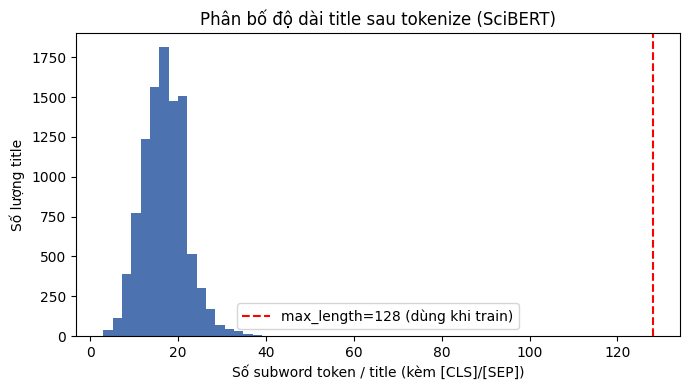

In [2]:
unk_id = tokenizer.unk_token_id
lengths, unk_counts = [], []
for title in papers_df["title"].tolist():
    ids = tokenizer(title, add_special_tokens=True, truncation=False)["input_ids"]
    lengths.append(len(ids))
    unk_counts.append(sum(1 for i in ids if i == unk_id))

lengths = np.array(lengths)
unk_counts = np.array(unk_counts)

print(f"min={lengths.min()} mean={lengths.mean():.1f} p50={np.percentile(lengths,50):.0f} "
      f"p95={np.percentile(lengths,95):.0f} p99={np.percentile(lengths,99):.0f} max={lengths.max()}")
for ml in (128, 256):
    exceed = (lengths > ml).sum()
    print(f"Titles exceeding max_length={ml}: {exceed} ({100*exceed/len(lengths):.2f}%)")

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=40, color="#4C72B0")
plt.axvline(128, color="red", linestyle="--", label="max_length=128 (dùng khi train)")
plt.xlabel("Số subword token / title (kèm [CLS]/[SEP])")
plt.ylabel("Số lượng title")
plt.title("Phân bố độ dài title sau tokenize (SciBERT)")
plt.legend()
plt.tight_layout()
plt.show()

### 1.2 Tỷ lệ UNK token — kiểm tra vocab SciBERT có phủ được thuật ngữ trong title hay không

In [3]:
total_unk = unk_counts.sum()
total_tok = lengths.sum()
titles_with_unk = (unk_counts > 0).sum()
print(f"Total tokens: {total_tok}, total UNK: {total_unk} ({100*total_unk/total_tok:.3f}%)")
print(f"Titles containing >=1 UNK token: {titles_with_unk} ({100*titles_with_unk/len(papers_df):.2f}%)")

Total tokens: 169361, total UNK: 0 (0.000%)
Titles containing >=1 UNK token: 0 (0.00%)


### 1.3 Đối chiếu decode ngược input_ids <-> title gốc <-> nhãn multi-hot (spot check ngẫu nhiên)

Mục tiêu: xác nhận **không có lệch hàng** giữa văn bản và nhãn sau các bước xử lý DataFrame (groupby/sample/reset_index).

In [4]:
from dataset import build_label_mapping

label2id_full, id2label_full = build_label_mapping(papers_df, "taxonomy.csv")

sample_indices = random.sample(range(len(papers_df)), 8)
rows = []
for idx in sample_indices:
    row = papers_df.iloc[idx]
    enc = tokenizer(
        row["title"], add_special_tokens=True, max_length=MAX_LENGTH_USED,
        padding="max_length", truncation=True, return_tensors="pt",
    )
    input_ids = enc["input_ids"][0].tolist()
    decoded = tokenizer.decode(input_ids, skip_special_tokens=True)
    labels_vec = row_to_labels(row, label2id_full)
    positive_ids = [id2label_full[i] for i in np.nonzero(labels_vec)[0].tolist()]
    positive_names = [f"{tid}:{topic_name.get(tid,'?')}" for tid in positive_ids]
    rows.append({
        "idx": idx,
        "title_goc": row["title"],
        "decoded": decoded,
        "nhan_duong_tinh": "; ".join(positive_names),
    })

pd.set_option("display.max_colwidth", 120)
display(pd.DataFrame(rows))

,idx,title_goc,decoded,nhan_duong_tinh
0,1824,Group-TopK: Optimizing Distributed Training on Edge Devices via Communication Compression,group - topk : optimizing distributed training on edge devices via communication compression,10003100:Cloud computing; 10010172:Distributed algorithms; 10010258:Learning paradigms; 10010293:Machine learning ap...
1,409,Development of Uzbek Question-Answering Models through Fine-Tuning Approaches,development of uzbek question - answering models through fine - tuning approaches,10003338:Retrieval models and ranking; 10010179:Natural language processing; 10010473:Language translation
2,4506,ActRef: Enhancing the Understanding of Python Code Refactoring with Action-Based Analysis,actref : enhancing the understanding of python code refactoring with action - based analysis,10003146:Visualization techniques
3,4012,DDialogue: A Collaborative Framework for Cross-Sectoral Dialogue through Data,ddialogue : a collaborative framework for cross - sectoral dialogue through data,"10003131:Collaborative and social computing theory, concepts and paradigms; 10003527:Computing education"
4,3657,"Session Summary Podcast: Session 25: Community, Justice, and Design","session summary podcast : session 25 : community, justice, and design",10002945:Surveys and overviews
5,2286,Luma,luma,10010224:Computer vision
6,1679,Resistance recognition and sorting system based on machine vision and robotic arm,resistance recognition and sorting system based on machine vision and robotic arm,10010439:Engineering
7,8935,The Evolution of Agile and Hybrid Project Management Methodologies: A Systematic Literature Review,the evolution of agile and hybrid project management methodologies : a systematic literature review,10011081:Software development process management


## 2. Phân bố nhãn: long-tail & class giao nhau

### 2.1 Số mẫu theo topic_id chính (primary) — kiểm tra long-tail

Unique primary topic_id: 99
min=89 median=102 mean=101.8 max=105
Số lớp có < 100 mẫu primary: 1


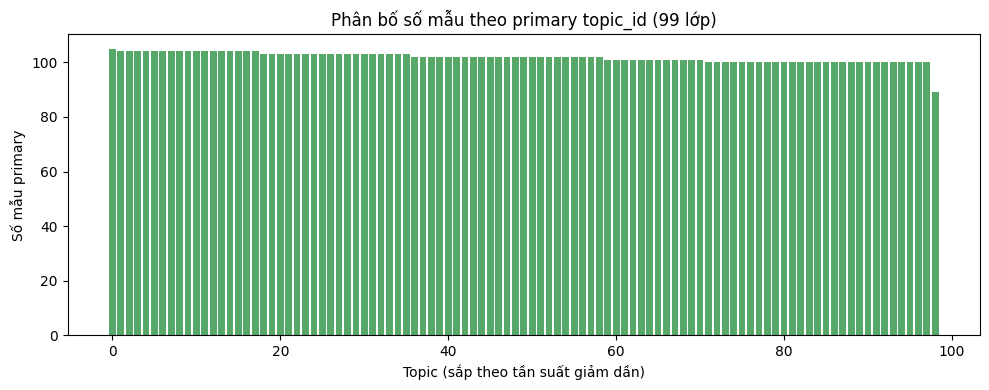

In [5]:
primary_counts = papers_df["topic_id"].value_counts()
print(f"Unique primary topic_id: {primary_counts.shape[0]}")
print(f"min={primary_counts.min()} median={primary_counts.median():.0f} "
      f"mean={primary_counts.mean():.1f} max={primary_counts.max()}")
print(f"Số lớp có < 100 mẫu primary: {(primary_counts < 100).sum()}")

plt.figure(figsize=(10, 4))
plt.bar(range(len(primary_counts)), primary_counts.values, color="#55A868")
plt.xlabel("Topic (sắp theo tần suất giảm dần)")
plt.ylabel("Số mẫu primary")
plt.title("Phân bố số mẫu theo primary topic_id (99 lớp)")
plt.tight_layout()
plt.show()

### 2.2 Tổng số lần xuất hiện mỗi nhãn (primary + secondary) — đây là phân bố thật sự dùng để tính `pos_weight`/BCE loss

In [6]:
label_cols_present = [c for c in LABEL_COLUMNS if c in papers_df.columns]
exposure_counter: dict = {}
for col in label_cols_present:
    vals = pd.to_numeric(papers_df[col], errors="coerce").dropna().astype(int)
    for v in vals:
        exposure_counter[v] = exposure_counter.get(v, 0) + 1

exposure = pd.Series(exposure_counter).sort_values(ascending=False)
print(f"Total exposure/label: min={exposure.min()} median={exposure.median():.0f} "
      f"mean={exposure.mean():.1f} max={exposure.max()} | max/min ratio={exposure.max()/exposure.min():.1f}x")

n_labels_per_paper = papers_df[label_cols_present].notna().sum(axis=1)
print(f"Avg labels/paper: {n_labels_per_paper.mean():.2f} | median: {n_labels_per_paper.median():.0f} "
      f"| max: {n_labels_per_paper.max()} | %chỉ có 1 nhãn: {100*(n_labels_per_paper==1).mean():.1f}%")

Total exposure/label: min=101 median=152 mean=178.0 max=920 | max/min ratio=9.1x
Avg labels/paper: 1.75 | median: 1 | max: 7 | %chỉ có 1 nhãn: 52.1%


### 2.3 Ma trận đồng xuất hiện — tìm các cặp lớp dễ "giao nhau" về ngữ nghĩa

In [7]:
pair_counter = Counter()
for _, row in papers_df.iterrows():
    labels = []
    for col in label_cols_present:
        val = row[col]
        if pd.isna(val):
            continue
        try:
            labels.append(int(float(val)))
        except (TypeError, ValueError):
            continue
    labels = sorted(set(labels))
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            pair_counter[(labels[i], labels[j])] += 1

top_pairs = pd.DataFrame(
    [
        {"topic_a": a, "ten_a": topic_name.get(a, "?"), "topic_b": b, "ten_b": topic_name.get(b, "?"), "so_lan_dong_xuat_hien": c}
        for (a, b), c in pair_counter.most_common(20)
    ]
)
display(top_pairs)

,topic_a,ten_a,topic_b,ten_b,so_lan_dong_xuat_hien
0,10010258,Learning paradigms,10010293,Machine learning approaches,227
1,10003113,Mobile networks,10003119,Wireless access networks,147
2,10010224,Computer vision,10010293,Machine learning approaches,89
3,10010179,Natural language processing,10010293,Machine learning approaches,80
4,10010071,Machine learning theory,10010293,Machine learning approaches,73
5,10010293,Machine learning approaches,10010321,Machine learning algorithms,69
6,10010087,Computational biology,10010450,Bioinformatics,69
7,10010071,Machine learning theory,10010258,Learning paradigms,65
8,10010179,Natural language processing,10010258,Learning paradigms,65
9,10010179,Natural language processing,10010473,Language translation,64


## 3. Thí nghiệm kiểm soát: 10 lớp x 100 mẫu (giữ multi-label)

Chọn 10 topic_id primary phổ biến nhất, lấy đúng 100 mẫu/lớp, restrict label space về đúng 10 lớp này
(nhãn phụ rơi ngoài 10 lớp bị bỏ). Train/eval với **đúng kiến trúc + hyperparameter** như lần chạy full-dataset
(`logs/20260717_144010.txt`, batch_size=64, lr=2e-5, epochs=20, dropout=0.2, max_pos_weight=10, warmup_ratio=0.1)
để so sánh công bằng.

In [8]:
NUM_CLASSES = 10
INSTANCES_PER_CLASS = 100

selected_topics = primary_counts.head(NUM_CLASSES).index.tolist()
print("10 lớp được chọn (primary phổ biến nhất):")
for t in selected_topics:
    print(f"  {t}: {topic_name.get(t,'?')} (n_primary={primary_counts[t]})")

parts = []
for t in selected_topics:
    group = papers_df[papers_df["topic_id"] == t]
    sampled = group.sample(n=INSTANCES_PER_CLASS, random_state=SEED)
    parts.append(sampled)
subset_df = pd.concat(parts, ignore_index=True)
print(f"\nSubset size: {len(subset_df)} papers x {NUM_CLASSES} classes")

label2id = {label: i for i, label in enumerate(sorted(selected_topics))}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(label2id)

train_df, test_df = split_by_primary_topic(subset_df, test_size=0.2, seed=SEED)
train_df = train_df.copy()
test_df = test_df.copy()
train_df["labels"] = [row_to_labels(row, label2id) for _, row in train_df.iterrows()]
test_df["labels"] = [row_to_labels(row, label2id) for _, row in test_df.iterrows()]
print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Avg labels/paper (train subset): {np.stack(train_df['labels'].to_numpy()).sum()/len(train_df):.2f}")

10 lớp được chọn (primary phổ biến nhất):
  10011130: Evaluation (n_primary=105)
  10003014: Network security (n_primary=104)
  10003023: Software security engineering (n_primary=104)
  10010382: Image manipulation (n_primary=104)
  10010224: Computer vision (n_primary=104)
  10010562: Embedded systems (n_primary=104)
  10010577: Reliability (n_primary=104)
  10010537: Distributed architectures (n_primary=104)
  10010293: Machine learning approaches (n_primary=104)
  10003131: Collaborative and social computing theory, concepts and paradigms (n_primary=104)

Subset size: 1000 papers x 10 classes
Train: 800 | Test: 200
Avg labels/paper (train subset): 1.16


### 3.0 Kiểm tra: việc restrict label space về 10 lớp có vô tình biến bài toán thành đơn nhãn không?

Khi chỉ giữ lại 10 lớp, các nhãn phụ (`other_topic_id_*`) rơi ngoài 10 lớp này bị bỏ qua khỏi vector multi-hot (không lọc bỏ paper). Điều này có thể làm bài toán **dễ hơn giả tạo** vì giảm hẳn số nhãn/paper, chứ không chỉ vì "10 lớp ít giao nhau hơn 99 lớp". Cell dưới đo trực tiếp mức độ ảnh hưởng.

In [ ]:
from dataset import build_label_mapping

n_labels_restricted = np.stack(train_df["labels"].to_numpy()).sum(axis=1)

label2id_full_check, _ = build_label_mapping(papers_df, "taxonomy.csv")
n_labels_full_for_subset = np.stack(
    [row_to_labels(row, label2id_full_check) for _, row in subset_df.iterrows()]
).sum(axis=1)

print("== Trong không gian 10 lớp (dùng để train subset) ==")
print(f"avg={n_labels_restricted.mean():.3f} | %chỉ 1 nhãn={100*(n_labels_restricted==1).mean():.1f}%")

print("\n== Nhãn THẬT của cùng các paper này trong không gian đầy đủ 99 lớp ==")
print(f"avg={n_labels_full_for_subset.mean():.3f} | %chỉ 1 nhãn={100*(n_labels_full_for_subset==1).mean():.1f}%")

n_dropped = n_labels_full_for_subset.sum() - n_labels_restricted.sum()
pct_dropped = 100 * n_dropped / n_labels_full_for_subset.sum()
print(f"\n=> {pct_dropped:.1f}% lượt nhãn phụ bị 'rơi rụng' do restrict label space về 10 lớp.")
print("=> Kết quả thí nghiệm 10x100 KHÔNG thể so sánh trực tiếp 1-1 với full dataset (99 lớp, đa nhãn đầy đủ);\n"
      "   một phần chênh lệch mAP đến từ việc bài toán bị đơn giản hóa về gần như đơn nhãn, không chỉ từ việc giảm số lớp.")

In [9]:
BATCH_SIZE = 64
EPOCHS = 20
LR = 2e-5
WEIGHT_DECAY = 0.01
DROPOUT = 0.2
MAX_POS_WEIGHT = 10.0
WARMUP_RATIO = 0.1

train_dataset = PapersDataset(train_df, tokenizer=tokenizer, max_length=MAX_LENGTH_USED)
test_dataset = PapersDataset(test_df, tokenizer=tokenizer, max_length=MAX_LENGTH_USED)

generator = torch.Generator()
generator.manual_seed(SEED)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = SciBERTMultiLabelClassifier(model_name=MODEL_NAME, num_labels=num_labels, dropout=DROPOUT).to(device)
pos_weight = compute_pos_weight(train_loader, device=device, max_weight=MAX_POS_WEIGHT)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"pos_weight min={pos_weight.min().item():.2f} max={pos_weight.max().item():.2f}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(total_steps * WARMUP_RATIO), num_training_steps=total_steps
)

pos_weight min=5.30 max=9.00


In [10]:
os.makedirs("diagnostics", exist_ok=True)
log_path = os.path.join("diagnostics", f"small_scale_notebook_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt")
with open(log_path, "w", encoding="utf-8") as f:
    f.write(f"# subset: {NUM_CLASSES} classes x {INSTANCES_PER_CLASS} instances, topics={selected_topics}\n")
    f.write("epoch\ttrain_loss\ttest_loss\tmAP\tF1-score\n")
print(f"Log: {log_path}")

history = []
for epoch in range(1, EPOCHS + 1):
    train_loss = run_one_epoch(
        model=model, data_loader=train_loader, criterion=criterion,
        optimizer=optimizer, scheduler=scheduler, device=device, epoch=epoch, log_steps=20,
    )
    test_loss, metrics = evaluate(model=model, data_loader=test_loader, criterion=criterion, device=device, epoch=epoch)
    print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} | test_loss={test_loss:.4f} "
          f"| mAP={metrics['mAP']:.4f} | F1={metrics['f1']:.4f}")
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(f"{epoch}\t{train_loss:.4f}\t{test_loss:.4f}\t{metrics['mAP']:.4f}\t{metrics['f1']:.4f}\n")
    history.append({"epoch": epoch, "train_loss": train_loss, "test_loss": test_loss, **metrics})

history_df = pd.DataFrame(history)
display(history_df)

Log: diagnostics/small_scale_notebook_20260720_095947.txt


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
Epoch 1 testing: 100%|██████████| 4/4 [00:03<00:00,  1.22it/s, avg_loss=1.1867, loss=1.1410]


Epoch  1 | train_loss=1.2582 | test_loss=1.1867 | mAP=0.2203 | F1=0.2011


Epoch 2 testing: 100%|██████████| 4/4 [00:01<00:00,  2.07it/s, avg_loss=1.0874, loss=1.0143]


Epoch  2 | train_loss=1.1830 | test_loss=1.0874 | mAP=0.3815 | F1=0.2203


...

Epoch 19 testing: 100%|██████████| 4/4 [00:01<00:00,  2.38it/s, avg_loss=1.0247, loss=1.0418]


Epoch 19 | train_loss=0.1475 | test_loss=1.0247 | mAP=0.6131 | F1=0.4863


Epoch 20 testing: 100%|██████████| 4/4 [00:01<00:00,  2.02it/s, avg_loss=1.0253, loss=1.0344]


Epoch 20 | train_loss=0.1460 | test_loss=1.0253 | mAP=0.6132 | F1=0.4867


,epoch,train_loss,test_loss,mAP,f1
0,1,1.258244,1.186672,0.220265,0.201060
1,2,1.183029,1.087443,0.381547,0.220300
2,3,1.034019,0.940213,0.493928,0.269419
3,4,0.833830,0.836956,0.546060,0.325282
4,5,0.697944,0.788139,0.574458,0.360589
5,6,0.585621,0.803045,0.585086,0.381433
6,7,0.501669,0.803805,0.586102,0.401974
7,8,0.442195,0.807607,0.611737,0.420460
8,9,0.378913,0.826209,0.611353,0.433431
9,10,0.333258,0.848136,0.607990,0.444408


### 3.1 So sánh mAP/F1: subset 10x100 vs full dataset (99 lớp)

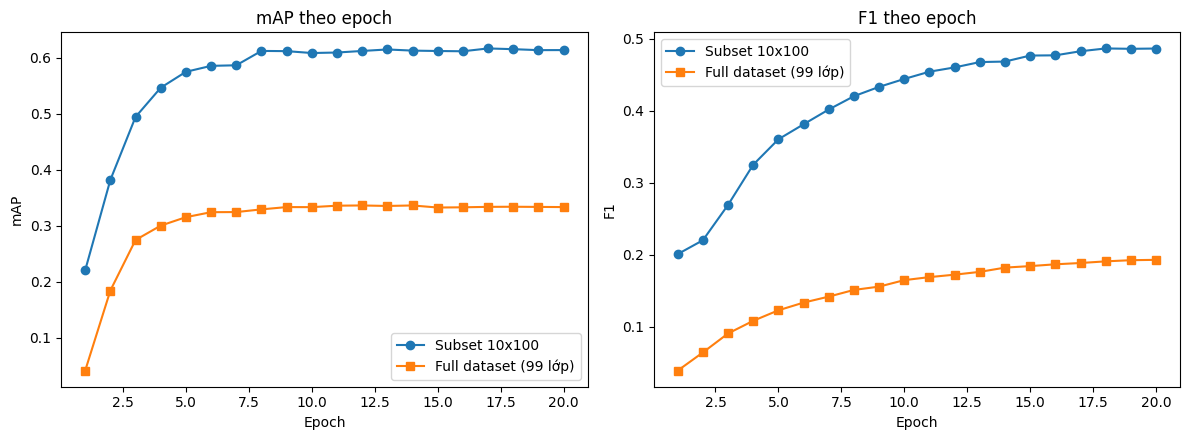

Best mAP subset 10x100: 0.6162 (epoch 17)
Best mAP full dataset : 0.3359 (epoch 12)


In [11]:
full_log_path = "logs/20260717_144010.txt"  # đổi lại nếu bạn có log full-dataset mới hơn
full_df = pd.read_csv(full_log_path, sep="\t")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history_df["epoch"], history_df["mAP"], marker="o", label="Subset 10x100")
axes[0].plot(full_df["epoch"], full_df["mAP"], marker="s", label="Full dataset (99 lớp)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("mAP"); axes[0].set_title("mAP theo epoch"); axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["f1"], marker="o", label="Subset 10x100")
axes[1].plot(full_df["epoch"], full_df["F1-score"], marker="s", label="Full dataset (99 lớp)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1"); axes[1].set_title("F1 theo epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Best mAP subset 10x100: {history_df['mAP'].max():.4f} (epoch {history_df.loc[history_df['mAP'].idxmax(),'epoch']})")
print(f"Best mAP full dataset : {full_df['mAP'].max():.4f} (epoch {full_df.loc[full_df['mAP'].idxmax(),'epoch']})")

## 4. Kết luận (điền sau khi chạy xong)

Điền vào đây theo đúng logic giáo sư đưa ra, dựa trên số liệu ở mục 3.1, **có tính đến caveat ở mục 3.0**:

- [ ] Best mAP subset 10x100 = ____ , Best mAP full dataset = ____
- [ ] Nếu subset **vẫn thấp** => nghi ngờ **lỗi pipeline** (xem lại mục 1 — tokenize/label alignment).
- [ ] Nếu subset **cao rõ rệt** => pipeline đúng, nhưng **PHẢI trừ hao** phần chênh lệch do mục 3.0 (bài toán bị đơn giản hóa gần thành đơn nhãn khi restrict còn 10 lớp, không chỉ do giảm class-overlap). Cân nhắc nêu trong báo cáo: "kết quả cho thấy pipeline hoạt động đúng và có tín hiệu học được, nhưng con số mAP tuyệt đối giữa 2 thí nghiệm không so sánh ngang hàng do khác biệt về mật độ đa nhãn".
- [ ] Kết hợp mục 2: mức mất cân bằng nhãn thật sự chỉ ~9x (không phải long-tail nặng); mục 2.3 cho thấy cụm Machine Learning/NLP đồng xuất hiện rất nhiều => vẫn nghiêng về giả thuyết **class giao nhau ở quy mô lớn** hơn là "ít ví dụ", nhưng thí nghiệm 10x100 hiện tại chỉ là bằng chứng gián tiếp/định tính, không phải định lượng chính xác do caveat đơn nhãn hóa.
- [ ] Ghi chú thêm: mục 1.3 cho thấy một số title rất ngắn/ít thông tin (vd chỉ 1 từ) trong khi `dataset.py` hiện chỉ tokenize title (abstract bị comment) — cân nhắc bật lại abstract như một hướng cải thiện độc lập.
- [ ] (Tuỳ chọn) Nếu muốn số liệu định lượng chặt hơn: chạy lại thí nghiệm nhưng KHÔNG restrict label space (giữ num_labels=99, chỉ giảm số lượng training sample xuống ~1000 balanced theo 10 lớp) để cô lập đúng biến "ít ví dụ" khỏi biến "đơn giản hóa đa nhãn".